In [111]:
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [112]:
# wczytanie modeli, datasetów
model_light_gbm = joblib.load("black_box_model.pkl")
model_reg = joblib.load("logistic_model.pkl")


X_train_box, y_train_box = joblib.load("train_light_gbm.pkl")
X_val_box, y_val_box = joblib.load("val_light_gbm.pkl")
X_test_box, y_test_box = joblib.load("test_light_gbm.pkl")


X_train_reg, y_train_reg = joblib.load("train_reg.pkl")
X_val_reg, y_val_reg = joblib.load("val_reg.pkl")
X_test_reg, y_test_reg = joblib.load("test_reg.pkl")

### Shap dla black boxa ale powinien działać po wstawieniu model_reg i zbiorów danych bez dodatkowych zmian

In [113]:
explainer = shap.TreeExplainer(model_light_gbm)

explainer = shap.LinearExplainer(model_reg, masker=X_train_reg.sample(100, random_state=42)) ##zakomentować żeby analizować lightgbm


X_val = X_val_box
y_val = y_val_box
X_test = X_test_box

X_val = X_val_reg  ##analogicznie zakomentować
y_val = y_val_reg
X_test = X_test_reg

#shap_values = explainer.shap_values(X_test_box)
shap_values = explainer.shap_values(X_test)


# Jeśli shap_values to lista (klasy 0 i 1) → bierz klasę 1
# Jeśli shap_values to macierz → użyj jej bez zmian
if isinstance(shap_values, list):
    shap_matrix = shap_values[1]   # klasa pozytywna
else:
    shap_matrix = shap_values      # macierz SHAP

print(shap_matrix.shape)



(450, 5)


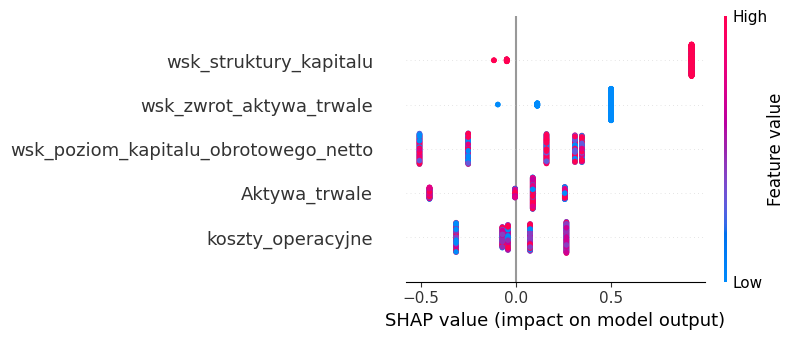

In [114]:
shap.summary_plot(shap_matrix, X_val, feature_names=X_val.columns)

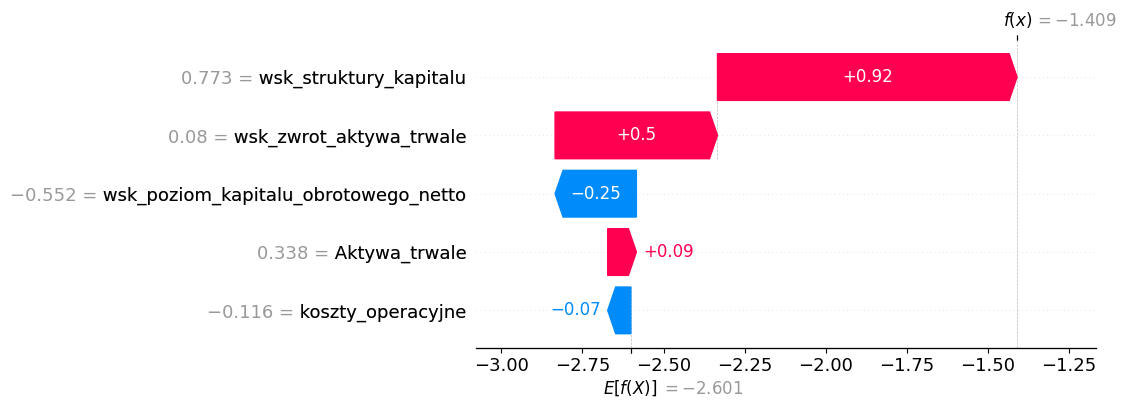

In [118]:
# Waterfall dla przykładowego defaultu

positive_idx = np.where(y_val == 1)[0]
idx = positive_idx[0] #przykładowa obserwacja
idx

shap.plots.waterfall(
    shap.Explanation(
        values=shap_matrix[idx],
        base_values=explainer.expected_value,
        data=X_val.iloc[idx],
        feature_names=X_val.columns
    )
)


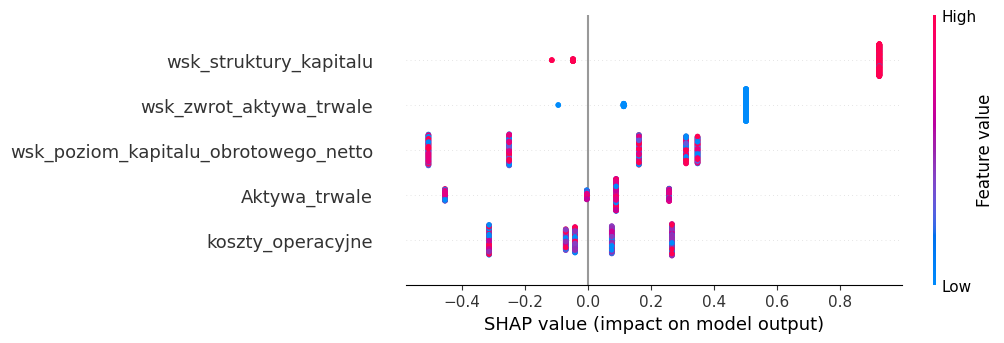

In [116]:
# Tworzymy obiekt Explanation
shap_exp = shap.Explanation(
    values=shap_matrix,
    base_values=explainer.expected_value,
    data=X_val,
    feature_names=X_val.columns
)

# Beeswarm plot
shap.plots.beeswarm(shap_exp)

## Scatter Plot - Relacja między wartością cechy a wpływem SHAP

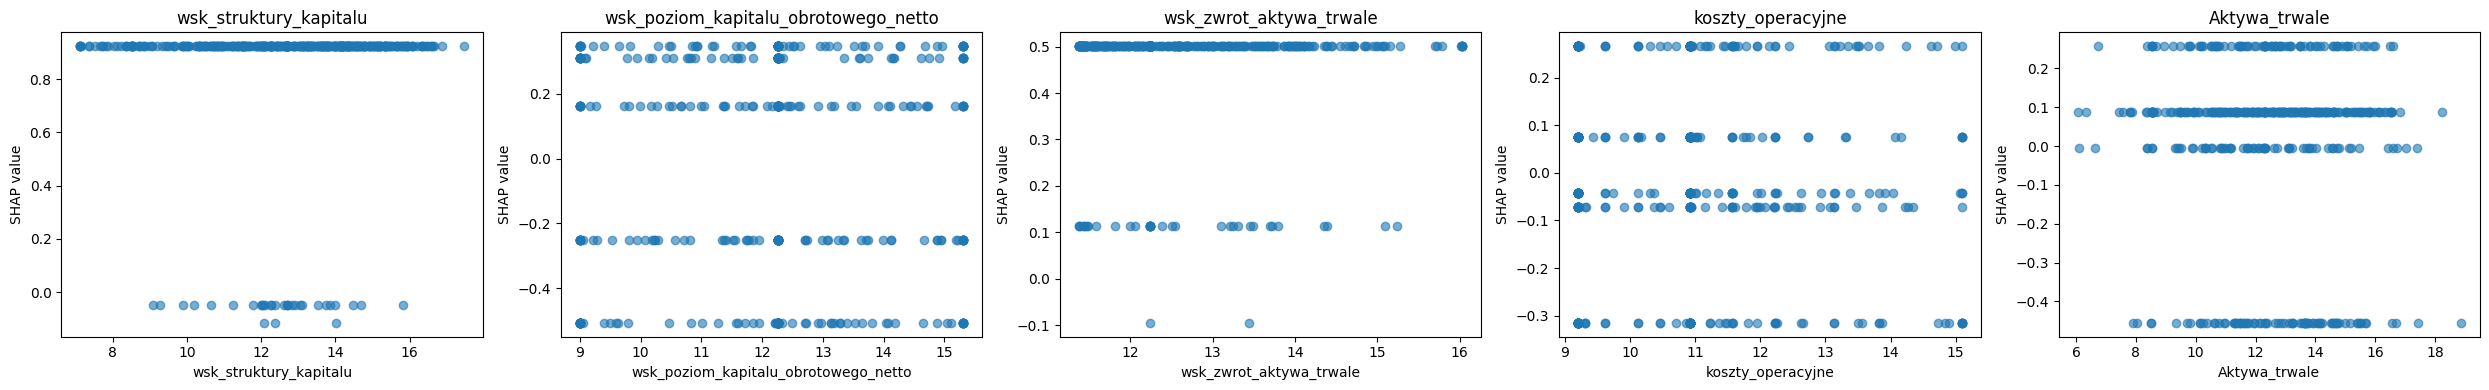

In [117]:
features = X_val.columns.tolist()
n_cols = 5
n_rows = (len(features) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols*5, n_rows*4))

for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i+1)
    col_idx = X_val.columns.get_loc(feature)
    # Scatter ręczny: SHAP vs wartość cechy
    plt.scatter(X_val_box.iloc[:, col_idx], shap_matrix[:, col_idx], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel("SHAP value")
    plt.title(feature)

plt.tight_layout()
plt.show()

### Dla regresji dobrze będzie przerzucić woe z preprocesingu na model, wtedy nie będzie takie zbinowane

### Dla lightgbm mamy poważny problem - nie widać żeby pojedyncze zmienne pozwalały tłumaczyć decyzje modelu